In [1]:
import pandas as pd

# Loading the data
url_emails_cleaned = 'https://raw.githubusercontent.com/Drakey-504/synthetic-phishing-generation-and-detection/main/data/processed/emails_clean.csv'
url_synthetic_phishing = 'https://raw.githubusercontent.com/Drakey-504/synthetic-phishing-generation-and-detection/main/data/processed/synthetic_phishing.csv'

emails_clean = pd.read_csv(url_emails_cleaned)
synthetic_phishing = pd.read_csv(url_synthetic_phishing)

print(emails_clean.columns.tolist())
print(synthetic_phishing.columns.tolist())

# labeled phishing or legitimate
# emails_clean
# synthetic_phishing.head()

['id', 'source', 'subject', 'text', 'label', 'split']
['id', 'method', 'sophistication', 'scenario', 'prompt_id', 'model', 'temperature', 'subject', 'text', 'label']


In [2]:
TEXT_COL = 'text'

label_map = {'legitimate': 0, 'phishing': 1}
synthetic_phishing['label'] = synthetic_phishing['label'].map(label_map)
emails_clean['label'] = emails_clean['label'].map(label_map)


emails_clean['source']        = 'real'
synthetic_phishing['source']  = 'synthetic'

combined = pd.concat([synthetic_phishing, emails_clean], ignore_index=True)
combined = combined[[TEXT_COL, 'label', 'source']].dropna()


# combined = pd.concat([synthetic_phishing, emails_clean], ignore_index=True)
# combined = combined[[TEXT_COL, 'label']].dropna()

print(combined[['label', 'source']].value_counts())
combined

label  source   
0      real         8398
1      real         4835
       synthetic     460
Name: count, dtype: int64


,text,label,source
0,"Dear Emily Chen,\n\nWe have temporarily suspen...",1,synthetic
1,"Dear Julia Rodriguez,\n\nWe've temporarily sus...",1,synthetic
2,"Dear Emily Wilson,\n\nWe're writing to inform ...",1,synthetic
3,"Dear Rachel Thompson,\n\nWe have temporarily s...",1,synthetic
4,"Dear Rachel Davis,\n\nWe've detected some unus...",1,synthetic
...,...,...,...
13688,http://news.bbc.co.uk/1/hi/england/2515127.stm...,0,real
13689,"> >-- be careful when using this one.) Also, t...",0,real
13690,">>>>> ""SM"" == Skip Montanaro writes:\n\nJeremy...",0,real
13691,"So then, ""Mark Hammond"" is all like:\n\n> So, ...",0,real


# DistilBERT

In [3]:
!pip install transformers datasets accelerate -q

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
import torch
print("GPU available:", torch.cuda.is_available())

GPU available: True


In [4]:
# part 2: data prep
df = emails_clean[[TEXT_COL, 'label']].dropna().reset_index(drop=True)

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
train_df, val_df = train_test_split(
    train_df, test_size=0.1, random_state=42, stratify=train_df['label']
)

print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")

# Convert to HuggingFace Datasets
train_ds = Dataset.from_pandas(train_df.rename(columns={TEXT_COL: 'text'})[['text', 'label']])
val_ds   = Dataset.from_pandas(val_df.rename(columns={TEXT_COL: 'text'})[['text', 'label']])
test_ds  = Dataset.from_pandas(test_df.rename(columns={TEXT_COL: 'text'})[['text', 'label']])

Train: 9527  Val: 1059  Test: 2647


In [5]:
# part 3: tokenizing

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=256,      # emails can be long — increase to 512 if GPU memory allows
    )

train_ds = train_ds.map(tokenize, batched=True)
val_ds   = val_ds.map(tokenize, batched=True)
test_ds  = test_ds.map(tokenize, batched=True)

# Set format for PyTorch
cols = ['input_ids', 'attention_mask', 'label']
train_ds.set_format(type='torch', columns=cols)
val_ds.set_format(type='torch', columns=cols)
test_ds.set_format(type='torch', columns=cols)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/9527 [00:00<?, ? examples/s]

Map:   0%|          | 0/1059 [00:00<?, ? examples/s]

Map:   0%|          | 0/2647 [00:00<?, ? examples/s]

In [7]:
# part 4: loading model
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds  = np.argmax(logits, axis=1)
    proba  = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return {
        'accuracy': (preds == labels).mean(),
        'roc_auc':  roc_auc_score(labels, proba),
    }

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [8]:
import torch

# part 5: training arguments
training_args = TrainingArguments(
    output_dir='./distilbert-phishing',
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,       # required for early stopping
    metric_for_best_model='roc_auc',
    greater_is_better=True,
    logging_steps=50,
    fp16=torch.cuda.is_available(),    # mixed precision if GPU available
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
                                       # stops if val roc_auc doesn't improve for 2 epochs
)

trainer.train()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Roc Auc
1,0.051145,0.022719,0.996223,0.998914
2,0.008690,0.010677,0.998111,0.998952
3,0.000245,0.045146,0.989613,0.998885
4,0.001349,0.020696,0.996223,0.998854


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=2384, training_loss=0.04473148410004601, metrics={'train_runtime': 320.5286, 'train_samples_per_second': 148.614, 'train_steps_per_second': 9.297, 'total_flos': 2524033813991424.0, 'train_loss': 0.04473148410004601, 'epoch': 4.0})

{'eval_loss': 0.02543255127966404, 'eval_accuracy': 0.9950887797506611, 'eval_roc_auc': 0.9997396218052889, 'eval_runtime': 4.4373, 'eval_samples_per_second': 596.531, 'eval_steps_per_second': 18.705, 'epoch': 4.0}
              precision    recall  f1-score   support

  Legitimate       0.99      1.00      1.00      1680
    Phishing       1.00      0.99      0.99       967

    accuracy                           1.00      2647
   macro avg       1.00      0.99      0.99      2647
weighted avg       1.00      1.00      1.00      2647

ROC-AUC: 0.9997

TP: 957  FP: 3  TN: 1677  FN: 10


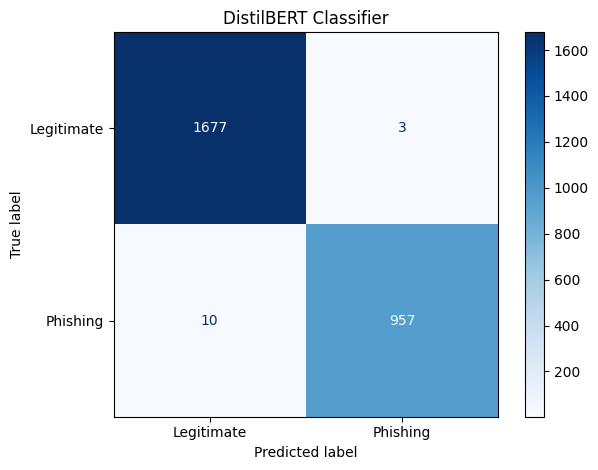

In [9]:
# # evaluating on test set
# results = trainer.evaluate(test_ds)
# print(results)

# predictions = trainer.predict(test_ds)
# y_pred  = np.argmax(predictions.predictions, axis=1)
# y_proba = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()[:, 1]

# print(classification_report(test_df['label'], y_pred,
#       target_names=['Legitimate', 'Phishing']))
# print(f"ROC-AUC: {roc_auc_score(test_df['label'], y_proba):.4f}")


from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# Evaluating on test set
results = trainer.evaluate(test_ds)
print(results)

predictions = trainer.predict(test_ds)
y_pred  = np.argmax(predictions.predictions, axis=1)
y_proba = torch.softmax(torch.tensor(predictions.predictions), dim=1).numpy()[:, 1]
y_true  = test_df['label'].values

print(classification_report(y_true, y_pred, target_names=['Legitimate', 'Phishing']))
print(f"ROC-AUC: {roc_auc_score(y_true, y_proba):.4f}")

# TP, FP, TN, FN
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
print(f"\nTP: {tp}  FP: {fp}  TN: {tn}  FN: {fn}")

# Confusion matrix plot
ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=['Legitimate', 'Phishing']
).plot(cmap='Blues')
plt.title('DistilBERT Classifier')
plt.tight_layout()
plt.show()